In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from segmentation_project.data.loader import ImageLoader
from segmentation_project.model_evaluation.evaluation import DiceScore, IoUScore
from segmentation_project.segmentation_models.sam_segmenter import SAMSegmenter

In [2]:
# Initialize loader
loader = ImageLoader()

# Define directories
auto_mask_dir = loader.project_root / "masks_auto"

manual_mask_dir = loader.project_root / "masks_manual"

In [3]:
# Store evaluation scores
dice_scores = []

iou_scores = []

image_names = []

# Get predicted masks
predicted_masks = sorted(auto_mask_dir.glob("mask_*.png"))

print(f"Found {len(predicted_masks)} " f"predicted masks.")

Found 10 predicted masks.


In [4]:
# Evaluate predicted masks

for predicted_mask_path in predicted_masks:
    try:
        # Extract original image stem
        image_stem = predicted_mask_path.stem.replace("mask_", "")

        print(f"\nEvaluating: " f"{image_stem}")

        # Load predicted mask
        predicted_mask = cv2.imread(
            str(predicted_mask_path),
            cv2.IMREAD_GRAYSCALE,
        )

        if predicted_mask is None:
            raise ValueError("Failed to load predicted mask.")

        # Build original image path
        image_path = loader.image_dir / f"{image_stem}.jpg"

        # Find corresponding manual mask
        manual_mask_path = loader.get_mask_path(image_path)

        # Load manual mask
        manual_mask = loader.load_mask(manual_mask_path)

        if manual_mask is None:
            raise ValueError("Failed to load manual mask.")

        # Remove singleton channel dimension

        predicted_mask = np.squeeze(predicted_mask)

        manual_mask = np.squeeze(manual_mask)

        # Resize manual mask if needed
        if manual_mask.shape != predicted_mask.shape:
            manual_mask = cv2.resize(
                manual_mask,
                (
                    predicted_mask.shape[1],
                    predicted_mask.shape[0],
                ),
            )

        # Compute Dice score
        dice = DiceScore.apply(
            predicted_mask=predicted_mask,
            ground_truth_mask=manual_mask,
        )

        # Compute IoU score
        iou = IoUScore.apply(
            predicted_mask=predicted_mask,
            ground_truth_mask=manual_mask,
        )

        # Store results
        dice_scores.append(dice)

        iou_scores.append(iou)

        image_names.append(image_stem)

        print(f"Dice: {dice:.4f} | " f"IoU: {iou:.4f}")

    except Exception as error:
        print(f"Skipped " f"{predicted_mask_path.name}: " f"{error}")


Evaluating: img_2268
Dice: 0.5102 | IoU: 0.3424

Evaluating: img_2269
Dice: 0.3497 | IoU: 0.2119

Evaluating: img_2270
Dice: 0.4814 | IoU: 0.3170

Evaluating: img_2271
Dice: 0.3951 | IoU: 0.2462

Evaluating: img_2272
Dice: 0.3837 | IoU: 0.2374

Evaluating: img_2273
Dice: 0.3724 | IoU: 0.2288

Evaluating: img_2274
Dice: 0.5011 | IoU: 0.3343

Evaluating: img_2275
Dice: 0.4263 | IoU: 0.2709

Evaluating: img_2276
Dice: 0.5052 | IoU: 0.3380

Evaluating: img_2277
Dice: 0.5090 | IoU: 0.3414


In [5]:
# Compute summary statistics

mean_dice = np.mean(dice_scores)
std_dice = np.std(dice_scores)

mean_iou = np.mean(iou_scores)
std_iou = np.std(iou_scores)

print("\nEvaluation Summary")

print(f"Mean Dice Score: " f"{mean_dice:.4f}")

print(f"Dice Standard Deviation: " f"{std_dice:.4f}")

print(f"Mean IoU Score: " f"{mean_iou:.4f}")

print(f"IoU Standard Deviation: " f"{std_iou:.4f}")


Evaluation Summary
Mean Dice Score: 0.4434
Dice Standard Deviation: 0.0611
Mean IoU Score: 0.2868
IoU Standard Deviation: 0.0502


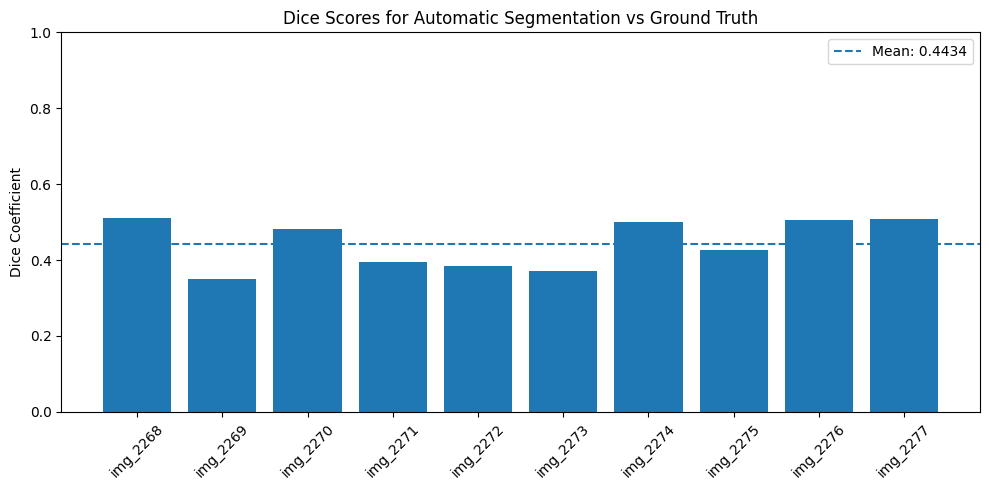

In [6]:
# Dice score visualization

plt.figure(figsize=(10, 5))

plt.bar(
    image_names,
    dice_scores,
)

plt.axhline(
    y=mean_dice,
    linestyle="--",
    label=(f"Mean: " f"{mean_dice:.4f}"),
)

plt.title("Dice Scores for " "Automatic Segmentation " "vs Ground Truth")

plt.ylabel("Dice Coefficient")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

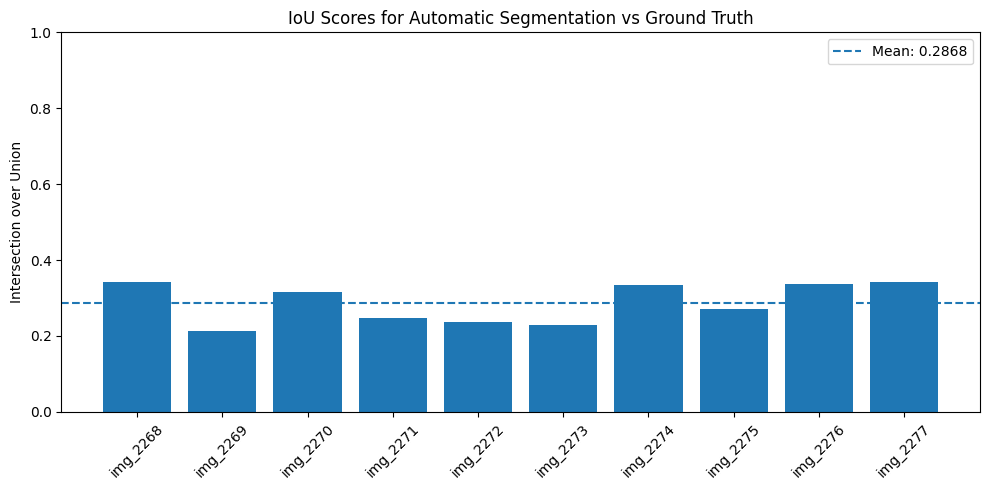

In [7]:
# IoU score visualization

plt.figure(figsize=(10, 5))

plt.bar(
    image_names,
    iou_scores,
)

plt.axhline(
    y=mean_iou,
    linestyle="--",
    label=(f"Mean: " f"{mean_iou:.4f}"),
)

plt.title("IoU Scores for " "Automatic Segmentation " "vs Ground Truth")

plt.ylabel("Intersection over Union")

plt.ylim(0, 1)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()